# Inequality-Constrained Optimization: Reaction Equilibrium via Barrier Method

This notebook demonstrates GMM and Flow Matching approaches for solving inequality-constrained optimization problems using the barrier method.

**Authors:** Victor Alves and John R. Kitchin

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.8 (main, Jan 14 2025, 23:36:58) [Clang 19.1.6 ]
Platform: macOS-15.7.2-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.4
scipy                1.16.2
matplotlib           3.10.1


sklearn              1.7.2


torch                2.4.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 15:16:56
Initial memory usage: 318.42 MB


## System Information

This section documents the computational environment used to run this notebook.

## Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import os

# Force CPU
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch

# Import reusable utilities
from generative_optimization import (
    generate_samples,
    best_gmm,
    ConditionalFlowMatching
)

# Figure settings for publication
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['legend.fontsize'] = 10

warnings.filterwarnings('ignore')

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

print("Setup complete")

Setup complete


---
## Reaction Equilibrium via Barrier Method

Consider the reversible reaction $A + B \rightleftharpoons 2C$ in a batch reactor. We seek the equilibrium extent of reaction $\xi$ where concentrations must remain non-negative.

With initial concentrations $C_{A0} = C_{B0} = 1$ mol/L and $C_{C0} = 0$:
- $C_A = 1 - \xi$
- $C_B = 1 - \xi$  
- $C_C = 2\xi$

The equilibrium condition:
$$K_{eq} = \frac{C_C^2}{C_A \cdot C_B} = \frac{(2\xi)^2}{(1-\xi)^2}$$

**Optimization formulation:** Minimize the squared equilibrium residual:
$$\min_\xi \quad f(\xi)^2 = \left[K_{eq}(1-\xi)^2 - 4\xi^2\right]^2$$

**Inequality constraints:** Concentrations must be non-negative, so $0 < \xi < 1$

**Barrier method:** We add logarithmic barrier terms to enforce the constraints:
$$\phi(\xi) = f(\xi)^2 - \mu \log(\xi) - \mu \log(1-\xi)$$

At the optimum, $\frac{d\phi}{d\xi} = 0$. We train generative models on $[\xi, \frac{d\phi}{d\xi}]$ and condition on the derivative being zero.

In [3]:
# Reaction equilibrium: A + B ⇌ 2C with BARRIER METHOD
import jax.numpy as jnp
from jax import grad

# Parameters
Keq = 1.0  # Equilibrium constant
mu = 0.001  # Barrier parameter

# Analytical solution
# Keq(1-ξ)² = 4ξ² → for Keq=1: (1-ξ)² = 4ξ² → 1-ξ = ±2ξ
# Physical root: ξ = 1/3
xi_analytical = 1/3

print("Reaction Equilibrium: A + B ⇌ 2C")
print(f"Keq = {Keq}")
print(f"Barrier parameter μ = {mu}")
print(f"\nAnalytical solution: ξ = {xi_analytical:.4f}")
print(f"Equilibrium concentrations:")
print(f"  CA = CB = {1 - xi_analytical:.4f} mol/L")
print(f"  CC = {2 * xi_analytical:.4f} mol/L")

# Define barrier objective
def barrier_equilibrium(xi):
    """Barrier objective: squared residual + log barriers for 0 < ξ < 1"""
    f = Keq * (1 - xi)**2 - 4 * xi**2
    obj = f**2
    barrier = -mu * jnp.log(xi) - mu * jnp.log(1 - xi)
    return obj + barrier

# Compute gradient of barrier objective
grad_barrier = grad(barrier_equilibrium)

# Also define residual for verification
def residual(xi):
    return Keq * (1 - xi)**2 - 4 * xi**2

# Verify with scipy
from scipy.optimize import minimize_scalar
result_scipy = minimize_scalar(lambda x: residual(x)**2, bounds=(0.01, 0.99), method='bounded')
print(f"\nScipy verification (min f²): ξ = {result_scipy.x:.6f}")
print(f"Verification: dφ/dξ at ξ=1/3: {float(grad_barrier(1/3)):.6f} (should be ≈ 0)")

Reaction Equilibrium: A + B ⇌ 2C
Keq = 1.0
Barrier parameter μ = 0.001

Analytical solution: ξ = 0.3333
Equilibrium concentrations:
  CA = CB = 0.6667 mol/L
  CC = 0.6667 mol/L

Scipy verification (min f²): ξ = 0.333334
Verification: dφ/dξ at ξ=1/3: -0.001499 (should be ≈ 0)


### Train GMM with Barrier Method

In [4]:
# Generate training data: sample ξ in feasible region, compute barrier gradient
n_samples = 2000
np.random.seed(42)
xi_samples = np.random.uniform(0.02, 0.98, n_samples)

# Compute barrier gradients at each sample point
gradients = np.array([float(grad_barrier(float(xi))) for xi in xi_samples])

# Build joint dataset: [ξ, dφ/dξ]
data_gmm = np.column_stack([xi_samples, gradients])

print(f"Training data shape: {data_gmm.shape}")
print(f"Columns: [ξ, dφ/dξ]")
print(f"ξ range: [{xi_samples.min():.3f}, {xi_samples.max():.3f}]")
print(f"Gradient range: [{gradients.min():.3f}, {gradients.max():.3f}]")

# Train GMM
print(f"\n{'='*60}")
print("Training GMM on barrier objective gradients...")
gmm, gmm_info = best_gmm(data_gmm, verbose=False)
print(f"Best GMM: {gmm_info['best_k']} components")

Training data shape: (2000, 2)
Columns: [ξ, dφ/dξ]
ξ range: [0.023, 0.980]
Gradient range: [-4.125, 60.539]

Training GMM on barrier objective gradients...


Best GMM: 25 components


In [5]:
# GMM: condition on gradient = 0 (barrier method optimization)
c_gmm = gmm.condition([1], [[0.0]])
xi_gmm_samples = c_gmm.sample(1000)[:, 0]

# Filter to valid range
xi_gmm_samples = xi_gmm_samples[(xi_gmm_samples > 0) & (xi_gmm_samples < 1)]

print("GMM Solution (conditioning on dφ/dξ = 0):")
print(f"  ξ = {xi_gmm_samples.mean():.4f} ± {xi_gmm_samples.std():.4f}")
print(f"  Analytical: ξ = {xi_analytical:.4f}")
print(f"  |Residual| at mean: {abs(residual(xi_gmm_samples.mean())):.6f}")

GMM Solution (conditioning on dφ/dξ = 0):
  ξ = 0.3345 ± 0.0012
  Analytical: ξ = 0.3333
  |Residual| at mean: 0.004730


### Train Flow Matching with Barrier Method

In [6]:
# Train Flow Matching: generate ξ conditioned on dφ/dξ
# x_data: ξ values to generate
# c_data: barrier gradient values to condition on

x_data_fm = xi_samples.reshape(-1, 1)
c_data_fm = gradients.reshape(-1, 1)

fm = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=64, n_layers=3)
print("Training Flow Matching on barrier objective gradients...")
fm_history = fm.fit(x_data_fm, c_data_fm, epochs=2000, batch_size=64, verbose=False)
print("  Training complete")

Training Flow Matching on barrier objective gradients...


  Training complete


In [7]:
# FM: condition on gradient = 0 (barrier method optimization)
xi_fm_samples = fm.sample(c_values=[[0.0]], n_samples=1000, n_steps=200)[:, 0]

# Filter to valid range
xi_fm_samples = xi_fm_samples[(xi_fm_samples > 0) & (xi_fm_samples < 1)]

print("Flow Matching Solution (conditioning on dφ/dξ = 0):")
print(f"  ξ = {xi_fm_samples.mean():.4f} ± {xi_fm_samples.std():.4f}")
print(f"  Analytical: ξ = {xi_analytical:.4f}")
print(f"  |Residual| at mean: {abs(residual(xi_fm_samples.mean())):.6f}")

Flow Matching Solution (conditioning on dφ/dξ = 0):
  ξ = 0.3322 ± 0.0022
  Analytical: ξ = 0.3333
  |Residual| at mean: 0.004475


### Publication Figure: Reaction Equilibrium via Barrier Method

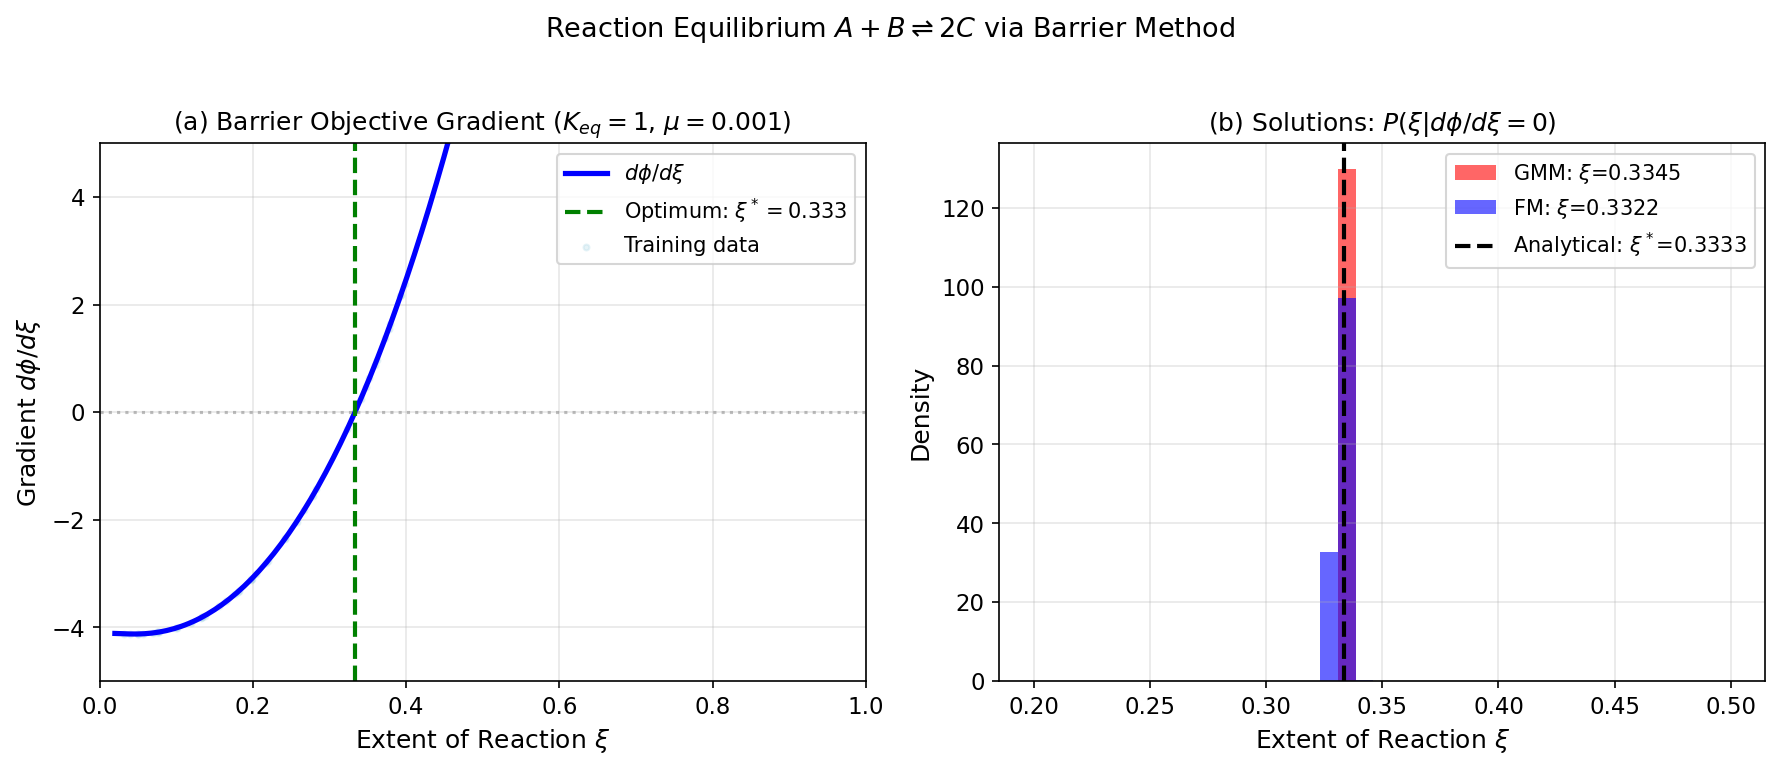


Figure saved as 'equilibrium_comparison.png'


In [8]:
# Create publication figure: 2-panel layout for barrier method
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ============================================================
# Left: Barrier objective gradient
# ============================================================
xi_plot = np.linspace(0.02, 0.98, 200)
grad_plot = np.array([float(grad_barrier(xi)) for xi in xi_plot])

ax1.plot(xi_plot, grad_plot, 'b-', lw=2.5, label='$d\\phi/d\\xi$')
ax1.axhline(0, color='gray', ls=':', alpha=0.5)
ax1.axvline(xi_analytical, color='green', ls='--', lw=2, label=f'Optimum: $\\xi^*={xi_analytical:.3f}$')
ax1.scatter(xi_samples[::20], gradients[::20], s=8, alpha=0.3, c='lightblue', label='Training data')

ax1.set_xlabel('Extent of Reaction $\\xi$')
ax1.set_ylabel('Gradient $d\\phi/d\\xi$')
ax1.set_title('(a) Barrier Objective Gradient ($K_{eq}=1$, $\\mu=0.001$)')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(-5, 5)

# ============================================================
# Right: Distribution of solutions from both methods
# ============================================================
bins = np.linspace(0.2, 0.5, 40)

ax2.hist(xi_gmm_samples, bins=bins, alpha=0.6, color='red', 
         label=f'GMM: $\\xi$={xi_gmm_samples.mean():.4f}', density=True)
ax2.hist(xi_fm_samples, bins=bins, alpha=0.6, color='blue', 
         label=f'FM: $\\xi$={xi_fm_samples.mean():.4f}', density=True)

ax2.axvline(xi_analytical, color='black', ls='--', lw=2, label=f'Analytical: $\\xi^*$={xi_analytical:.4f}')

ax2.set_xlabel('Extent of Reaction $\\xi$')
ax2.set_ylabel('Density')
ax2.set_title('(b) Solutions: $P(\\xi | d\\phi/d\\xi = 0)$')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Reaction Equilibrium $A + B \\rightleftharpoons 2C$ via Barrier Method', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('equilibrium_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'equilibrium_comparison.png'")

### Quantitative Comparison

In [9]:
print("Reaction Equilibrium via Barrier Method: A + B ⇌ 2C")
print("=" * 70)
print(f"Equilibrium constant: Keq = {Keq}")
print(f"Barrier parameter: μ = {mu}")
print()

print(f"{'Method':<25} {'ξ (mean ± std)':<25} {'|Residual|':<15}")
print("-" * 65)

# Analytical
print(f"{'Analytical':<25} {xi_analytical:.4f}                    {abs(residual(xi_analytical)):<15.6f}")

# Scipy
print(f"{'Scipy (bounded)':<25} {result_scipy.x:.4f}                    {abs(residual(result_scipy.x)):<15.6f}")

# GMM
xi_gmm_mean = xi_gmm_samples.mean()
xi_gmm_std = xi_gmm_samples.std()
print(f"{'GMM (barrier method)':<25} {xi_gmm_mean:.4f} ± {xi_gmm_std:.4f}          {abs(residual(xi_gmm_mean)):<15.6f}")

# FM
xi_fm_mean = xi_fm_samples.mean()
xi_fm_std = xi_fm_samples.std()
print(f"{'FM (barrier method)':<25} {xi_fm_mean:.4f} ± {xi_fm_std:.4f}          {abs(residual(xi_fm_mean)):<15.6f}")

Reaction Equilibrium via Barrier Method: A + B ⇌ 2C
Equilibrium constant: Keq = 1.0
Barrier parameter: μ = 0.001

Method                    ξ (mean ± std)            |Residual|     
-----------------------------------------------------------------
Analytical                0.3333                    0.000000       
Scipy (bounded)           0.3333                    0.000004       
GMM (barrier method)      0.3345 ± 0.0012          0.004730       
FM (barrier method)       0.3322 ± 0.0022          0.004475       


### Summary: Barrier Method for Inequality-Constrained Optimization

This example demonstrates how to handle inequality constraints using the **barrier method** within the generative optimization framework.

**Key observations:**

1. **Barrier formulation:** Instead of finding roots directly, we formulated an optimization problem: minimize $f(\xi)^2$ subject to $0 < \xi < 1$. The barrier objective $\phi(\xi) = f(\xi)^2 - \mu\log(\xi) - \mu\log(1-\xi)$ incorporates the constraints.

2. **Gradient conditioning:** Both GMM and Flow Matching are trained on $[\xi, \frac{d\phi}{d\xi}]$ and conditioned on the gradient being zero, which characterizes the optimum.

3. **Constraint enforcement:** The logarithmic barrier terms naturally keep solutions away from the boundaries ($\xi = 0$ and $\xi = 1$), ensuring physically meaningful results.

4. **Accuracy:** Both methods successfully identify the equilibrium extent $\xi \approx 1/3$, with residuals close to zero.

**Advantages of the barrier method:**
- Transforms constrained problems into unconstrained optimization via augmented objectives
- Gradient-based conditioning provides smooth, well-behaved training data
- Barrier terms prevent infeasible solutions without hard boundary enforcement
- Same generative framework (condition on gradient = 0) works for both unconstrained and constrained problems

**Practical considerations:**
- The barrier parameter $\mu$ controls the trade-off between constraint satisfaction and objective minimization
- Small $\mu$ values (like 0.001 used here) give solutions very close to the constraint boundaries when needed
- Training data should be sampled within the strictly feasible interior to avoid numerical issues with log barriers

In [10]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 15:16:56
End time:        2025-12-18 15:17:57
Elapsed time:    60.97 seconds (1.02 minutes)
----------------------------------------------------------------------
Initial memory:  318.42 MB
Final memory:    652.06 MB
Memory change:   +333.64 MB
